# Evidencia (Bloque 1)

**Nombre: Mauricio Olguín Sánchez**

**Matrícula: A01711522**

**Fabricante asignado: FAB3**

# Contexto

Se me ha contratado como ingeniero y analísta de datos en una tienda de productos que esta a nivel nacional. Se me ha encargado la tarea de revisar los tres principales frabricantes de productos lácteos que operena aquí. En mi caso, se me ha determinado trabajar en el registro del fabricante No. 3.

Los objetivos son los siguientes:

1. Ofrecer una visión general de la categoria de leche desglosado por fabricante en terminos de: a) composición de la cuota de mercado por año y; b) evolución de las ventas y los precios a lo largo de tiempo.
2. Realizar un análisis de correlación inicial para identificar relaciones siginificativas dentro de los datos.
3. Diseñar y ejcutar modelos de regresión para estimar la sensibilidad al precio del producto principal del fabricante asignado.
4. Proponer una mejora para el diseño del modelo con el fin de incorporar los siguientes factores: elasiticidad de precio curzada con otros productos, estacionalidad y tendencia de crecimiento.
5. Modificar el modelo añadiendo variables que incorporen los efecots de la estaionalidad y la tendencia de crecimiento del volumen.
6. Proponer como una predicción del precio y ventas del producto más vendido para los próximos 24 meses.

# Parte 1: Visión general y limpieza de datos

Para iniciar el análisis, cargamos y exploramos los datos.

In [18]:
# Librerias necesarias a lo largo de todo el proyecto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

df = pd.read_excel("./DATA_VENTAS.xlsx")
df

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,19.968037,73,239.616438,12
1,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,19.942040,223,239.304484,12
2,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,19.787868,319,237.454420,12
3,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,19.867904,307,238.414853,12
4,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,20.247877,387,242.974522,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978,12
3292,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344,12
3293,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188,12
3294,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654,12


Con estos datos, podemos ver que tenemos:
* 6 variables categóricas (2 que son fechas, 4 de cadenas de caracteres).
* 9 variables numéricas (3 de punto flotante y 6 de enteros).
* 803 instancias para FAB3
* 15 columnas/features

También, una primera impresión de lo que trata cada columna podría ser lo siguiente:

|Columna|Descripción|
|-|-|
|CORTE|Desconocido (más adelante se indagrá si es útil o no)|
|FABRICANTE|ID del fabricante|
|ID|ID del producto|
|AÑO1|Año del registro|
|SEMANA|Semana de registro de los datos|
|MES|Mes del registro de los datos|
|FECHAW|Fecha específica de la semana en la que empezaron los datos|
|FECHAM|Fecha específica del mes en la que se hizo el registro|
|VENTA_VALOR|Venta total durante esa semana|
|LITROS|Cantidad en lítros del producto|
|PRECIO_UNITARIO_LITRO|Precio por cada unidad de litro vendida de ese producto|
|PARQUETES|Docena de paquetes vendidos del producto|
|PRECIO_UNITARIO_PAQUETE|Precio por cada paquete vendido|
|UNIDADES_ENPAQUETE|Cantidad de unidades del producot en un paquete|

Antes de eliminar variables o agrupar registros se revisan:
- valores nulos;
- duplicados exactos;
- un mismo ID asociado a varios nombres;
- un mismo nombre asociado a varios IDs;
- consistencia de fechas y variables numéricas;
- columnas constantes o potencialmente redundantes.

In [19]:
# Valores nulos
null_summary = (
    df.isna()
    .sum()
    .to_frame("nulos")
    .assign(pct_nulos=lambda x: 100 * x["nulos"] / len(df))
    .sort_values("nulos", ascending=False)
)

null_summary

,nulos,pct_nulos
PRECIO_UNITARIO_LITRO,3,0.091019
PRECIO_UNITARIO_PAQUETE,3,0.091019
CORTE,0,0.000000
FABRICANTE,0,0.000000
ID,0,0.000000
PRODUCTO,0,0.000000
AÑO1,0,0.000000
SEMANA,0,0.000000
MES,0,0.000000
FECHAW,0,0.000000


Al ser tan pocos datos, resulta entonces viable eliminar estas instancias.

In [20]:
print(df.shape)

df = df.dropna()
df

(3296, 15)


,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,19.968037,73,239.616438,12
1,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,19.942040,223,239.304484,12
2,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,19.787868,319,237.454420,12
3,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,19.867904,307,238.414853,12
4,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,20.247877,387,242.974522,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978,12
3292,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344,12
3293,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188,12
3294,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654,12


Ahora, revisaré con diferentes filtro si es que existen datos duplicados. Primero, revisaré por duplicaciones exactas.

In [21]:
exact_duplicates = df.duplicated().sum()
print(f"Duplicados exactos: {exact_duplicates:,}")

Duplicados exactos: 0


Duplicaciones con el mismo ID

In [22]:
id_to_product = (
    df.groupby("ID", dropna=False)["PRODUCTO"]
    .nunique(dropna=False)
    .sort_values(ascending=False)
)

print("IDs con más de un nombre:")
display(id_to_product[id_to_product > 1].to_frame("num_nombres"))

IDs con más de un nombre:


,num_nombres
ID,


Duplicaciones con varios IDs

In [23]:
product_to_id = (
    df.groupby("PRODUCTO", dropna=False)["ID"]
    .nunique(dropna=False)
    .sort_values(ascending=False)
)

print("Productos con más de un ID:")
display(product_to_id[product_to_id > 1].to_frame("num_ids"))

Productos con más de un ID:


,num_ids
PRODUCTO,


Duplicacion por `PRODUCTO`,`AÑO` y `SEMANA`.

In [24]:
duplicados_logicos = df[df.duplicated(subset=['PRODUCTO', 'AÑO1', 'SEMANA'], keep=False)]
duplicados_logicos.sort_values(by=['PRODUCTO', 'AÑO1', 'SEMANA'])

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1629,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,211303.67,9336,22.633212,778,271.598548,12
1630,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,8397.00,396,21.204545,33,254.454545,12
1631,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,210346.78,10116,20.793474,843,249.521684,12
1632,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,80793.00,3924,20.589450,327,247.073394,12
1633,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,43,10,2024-10-21,2024-10-01,40552.91,1884,21.524899,157,258.298790,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978,12
3292,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344,12
3293,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188,12
3294,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654,12


Observando los datos que nos ha regresado podemos ver que, en efecto, existen datos duplicados, sin embargo, no son datos duplicados "al azar" o por error. Podemos ver que, aunque sí que se repiten por año, semana, mes, fechaw y fehcam, sus precio unitario por litro cambia. Esto es un gran indicador de que, muy probablemente, el precio durante esa semana cambió del producto en algún punto de venta. Entonces, valdría la pena, en vez de eliminar los datos con menor venta, sumar las ventas que se realizaron, los litros vendidos y el número de paquetes.

Para las columnas de precio unitario por litro y precio unitario por paquete, teneemos que tener cuidad de no sumarlas, sino de calcularles un nuevo precio que represente lo mejor posible el precio al que se vendieron durante esa semana. Una primera intuición podría ser calcular el precio promedio de entre las ambos datos, pero esto no representaría de la mejor forma nuestros datos ya que, como se pueden observar en el número de paquetes, la diferencia entre un dato y otro en el número de paquetes vendidos es mayor o mucho mayor.

Por lo cual, podría entonces convenir utilizar un precio promedio ponderado para recalcular los precios. Con un promedio "normal", le asignamos el mismo precio a todas las cantidades de los productos, con uno ponderado, le damos un mayor peso a los precios que se vendieron más y uno menor al que vendió menos y, con esto, se vuelve más representativo el valor del precio del producto.

In [25]:
# Columnas a agrupar
columnas_agrupacion = ['FABRICANTE', 'PRODUCTO', 'ID', 'AÑO1', 'SEMANA', 'MES', 'FECHAW', 'FECHAM']
# No recuperarmos UNIDADES_EN_PAQUETE ni CORTE porque no nos resultan utilies pues, ambas columnas
# repiten el mismo valor para todas las instancias.

# Agrupamos sumando el dinero, los litros y los paquetes
df_limpio = df.groupby(columnas_agrupacion, as_index=False).agg({
    'VENTA_VALOR': 'sum',
    'LITROS': 'sum',
    'PAQUETES': 'sum'
})

# Recalculamos los precios unitarios correctos de la semana
df_limpio['PRECIO_UNITARIO_LITRO'] = df_limpio['VENTA_VALOR'] / df_limpio['LITROS']
df_limpio['PRECIO_UNITARIO_PAQUETE'] = df_limpio['VENTA_VALOR'] / df_limpio['PAQUETES']
df = df_limpio
df


,FABRICANTE,PRODUCTO,ID,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
0,FAB1,FAB1_1L Sel Des Deslactosada,1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,73,19.968037,239.616438
1,FAB1,FAB1_1L Sel Des Deslactosada,1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,223,19.942040,239.304484
2,FAB1,FAB1_1L Sel Des Deslactosada,1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,319,19.787868,237.454420
3,FAB1,FAB1_1L Sel Des Deslactosada,1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,307,19.867904,238.414853
4,FAB1,FAB1_1L Sel Des Deslactosada,1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,387,20.247877,242.974522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3012,FAB6,FAB6_12/1L Leche Y Pan En Tera,12/1L Leche Y Pan En Tera,2023,39,9,2023-09-25,2023-09-01,23628.00,1584,132,14.916667,179.000000
3013,FAB6,FAB6_12/1L Leche Y Pan En Tera,12/1L Leche Y Pan En Tera,2023,40,10,2023-10-02,2023-10-01,2660.00,180,15,14.777778,177.333333
3014,FAB6,FAB6_12/1L Leche Y Pan En Tera,12/1L Leche Y Pan En Tera,2023,41,10,2023-10-09,2023-10-01,179.00,12,1,14.916667,179.000000
3015,FAB6,FAB6_12/1L Leche Y Pan En Tera,12/1L Leche Y Pan En Tera,2023,48,11,2023-11-27,2023-11-01,-1020.00,-60,-5,17.000000,204.000000


Verificamos que cada registro se mantega intacto y que, efectivamente, no hay más duplicados.

In [26]:
# Verificar ¿alguna semana (FECHAW) mapea a más de un mes (FECHAM)?
chequeo_semanas = df.groupby('FECHAW')['FECHAM'].nunique()
print(f"Semanas que apuntan a más de un mes: {(chequeo_semanas > 1).sum()}  (debe ser 0)")

# Distribución de semanas por mes calendario (para justificar el colapso)
semanas_por_mes = (
    df.drop_duplicates(subset=['AÑO1', 'MES', 'SEMANA'])
    .groupby(['AÑO1', 'MES'])['SEMANA'].nunique()
)
print("\nMeses calendario según su número de semanas:")
print(semanas_por_mes.value_counts().sort_index())

# Colapso mensual
columnas_mensuales = ['FABRICANTE', 'PRODUCTO', 'ID', 'AÑO1', 'MES', 'FECHAM']
df_mensual = df_limpio.groupby(columnas_mensuales, as_index=False).agg({
    'VENTA_VALOR': 'sum',
    'LITROS': 'sum'
})
df_mensual['PRECIO_UNITARIO_LITRO'] = df_mensual['VENTA_VALOR'] / df_mensual['LITROS']

# Verificación de conservación de totales (semanal vs. mensual)
total_semanal = df_limpio['VENTA_VALOR'].sum()
total_mensual = df_mensual['VENTA_VALOR'].sum()
diferencia = total_semanal - total_mensual
print(f"\nTotal ventas (semanal):  {total_semanal:,.2f}")
print(f"Total ventas (mensual):  {total_mensual:,.2f}")
print(f"Diferencia:              {diferencia:,.6f}  (debe ser ~0)")
assert abs(diferencia) < 1, "Se perdió información al colapsar a mensual"

print(f"\nFilas semanales: {len(df_limpio):,}  ->  Filas mensuales: {len(df_mensual):,}")

Semanas que apuntan a más de un mes: 0  (debe ser 0)

Meses calendario según su número de semanas:
SEMANA
4    28
5    15
Name: count, dtype: int64

Total ventas (semanal):  2,292,961,809.85
Total ventas (mensual):  2,292,961,809.85
Diferencia:              0.000000  (debe ser ~0)

Filas semanales: 3,017  ->  Filas mensuales: 710


También destacaré la evolución del fabricante 3 a lo largo del tiempo, tanto en su volumen como en sus precios a lo largo del tiempo.

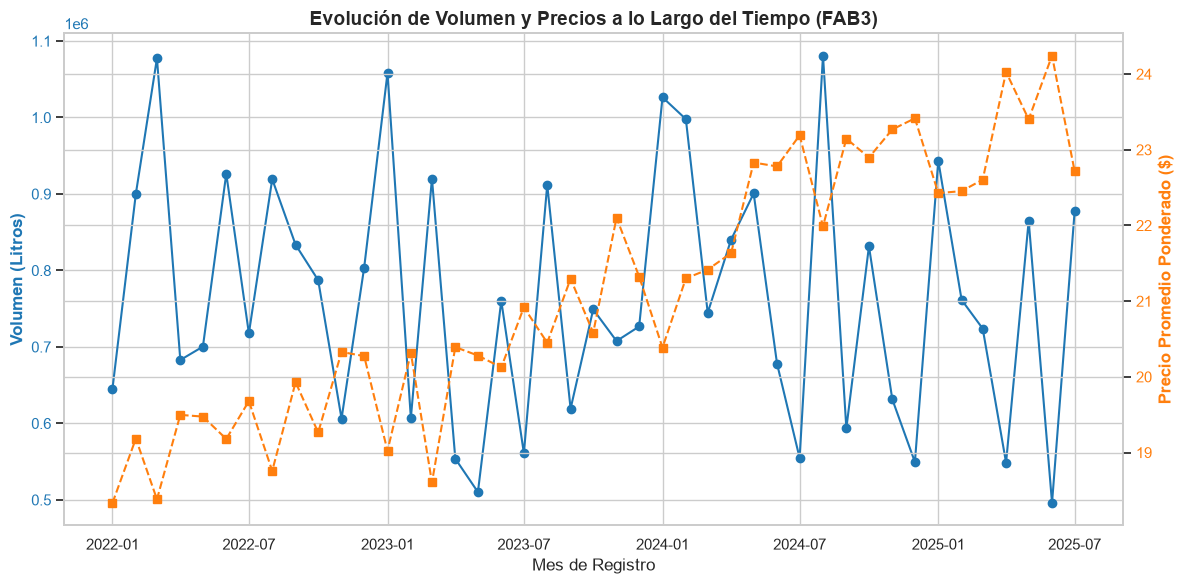

In [27]:
# Filtramos para el fabricante asignado (FAB3) usando el dataframe mensual
df_fab3_mensual = df_mensual[df_mensual["FABRICANTE"] == "FAB3"]

# Agrupamos por fecha mensual para ver la tendencia de toda la marca
evolucion_fab3 = df_fab3_mensual.groupby('FECHAM').agg({
    'LITROS': 'sum',
    'VENTA_VALOR': 'sum'
})
evolucion_fab3['PRECIO_PROMEDIO'] = evolucion_fab3['VENTA_VALOR'] / evolucion_fab3['LITROS']

# Gráfica de evolución con doble eje
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Mes de Registro', fontsize=12)
ax1.set_ylabel('Volumen (Litros)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(evolucion_fab3.index, evolucion_fab3['LITROS'], color=color1, marker='o', label='Litros Vendidos')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Precio Promedio Ponderado ($)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(evolucion_fab3.index, evolucion_fab3['PRECIO_PROMEDIO'], color=color2, marker='s', linestyle='--', label='Precio Promedio')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Evolución de Volumen y Precios a lo Largo del Tiempo (FAB3)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

Ahora que los datos ya están limpios, realizaré una descripción estadística inicial con la información básica de los mismos.

In [28]:
def resumen_desc(data, cols, nombre):
    tabla = data[cols].describe().T[['mean', 'std', '50%', 'min', 'max']]
    tabla.columns = ['Media', 'Desv. Estándar', 'Mediana', 'Mínimo', 'Máximo']
    print(f"\n--- {nombre} ---")
    display(tabla.round(2))
    return tabla

# Nivel mercado completo (todos los fabricantes)
resumen_desc(df_mensual, ['LITROS', 'PRECIO_UNITARIO_LITRO'], "Mercado completo (mensual)")

# Nivel FAB3 (agregando sus 3 productos) — df_fab3_mensual ya existe, viene de tu celda anterior
resumen_desc(df_fab3_mensual, ['LITROS', 'PRECIO_UNITARIO_LITRO', 'VENTA_VALOR'], "FAB3 (mensual, los 3 SKUs)")

# Nivel producto dentro de FAB3
for prod in df_fab3_mensual['PRODUCTO'].unique():
    sub = df_fab3_mensual[df_fab3_mensual['PRODUCTO'] == prod]
    resumen_desc(sub, ['LITROS', 'PRECIO_UNITARIO_LITRO'], prod)


--- Mercado completo (mensual) ---


,Media,Desv. Estándar,Mediana,Mínimo,Máximo
LITROS,159916.75,144507.84,98820.00,-144.00,787368.00
PRECIO_UNITARIO_LITRO,20.80,3.05,20.45,7.92,32.54



--- FAB3 (mensual, los 3 SKUs) ---


,Media,Desv. Estándar,Mediana,Mínimo,Máximo
LITROS,255280.28,162313.02,247740.00,55116.00,725052.00
PRECIO_UNITARIO_LITRO,21.32,1.69,21.03,17.78,25.04
VENTA_VALOR,5359086.79,3268066.82,5304993.82,1034818.98,13341026.07



--- FAB3_1L  D Li Deslactosada Light ---


,Media,Desv. Estándar,Mediana,Mínimo,Máximo
LITROS,77053.12,13566.81,75120.00,55116.00,104436.00
PRECIO_UNITARIO_LITRO,21.76,1.73,21.43,18.67,25.04



--- FAB3_1L  Desl Deslactosada ---


,Media,Desv. Estándar,Mediana,Mínimo,Máximo
LITROS,256995.91,56984.94,258768.00,169080.00,378900.00
PRECIO_UNITARIO_LITRO,21.28,1.51,21.22,18.62,24.12



--- FAB3_1L  Ent Entera ---


,Media,Desv. Estándar,Mediana,Mínimo,Máximo
LITROS,431791.81,111522.97,428460.00,242256.00,725052.00
PRECIO_UNITARIO_LITRO,20.92,1.76,20.64,17.78,24.25


## Objetivo 1: Cuota de mercado y Top Fabricantes

Para comprender la composición del mercado, analizando tanto su evolución histórica (anual) como su concentración reciente (últimos 12 meses), realizaré dos agrupaciones principales. Primero, agruparé los datos por la columna `AÑO1` y `FABRICANTE` sumando la variable `VENTA_VALOR` para calcular el porcentaje de participación anual de cada uno, visualizándolo mediante un gráfico de barras.

Luego, filtraré los registros correspondientes a los últimos 12 meses, calcularé la cuota individual de cada fabricante, y generaré una suma acumulada. Esto último lo representaré en un gráfico de Pareto (barras de participación individual combinadas con una línea de porcentaje acumulado) para identificar claramente qué fabricantes superan la barrera del 80% del mercado.

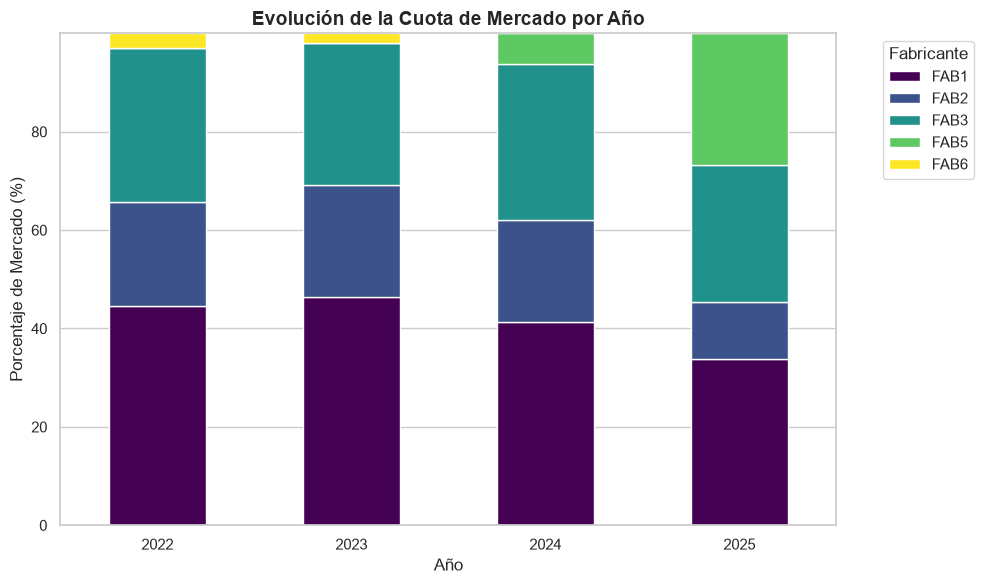

FABRICANTE,FAB1,FAB2,FAB3,FAB5,FAB6
AÑO1,,,,,
2022,44.64,21.03,31.42,0.00,2.92
2023,46.43,22.65,28.93,0.00,1.99
2024,41.39,20.74,31.55,6.33,0.00
2025,33.72,11.62,27.98,26.67,0.00


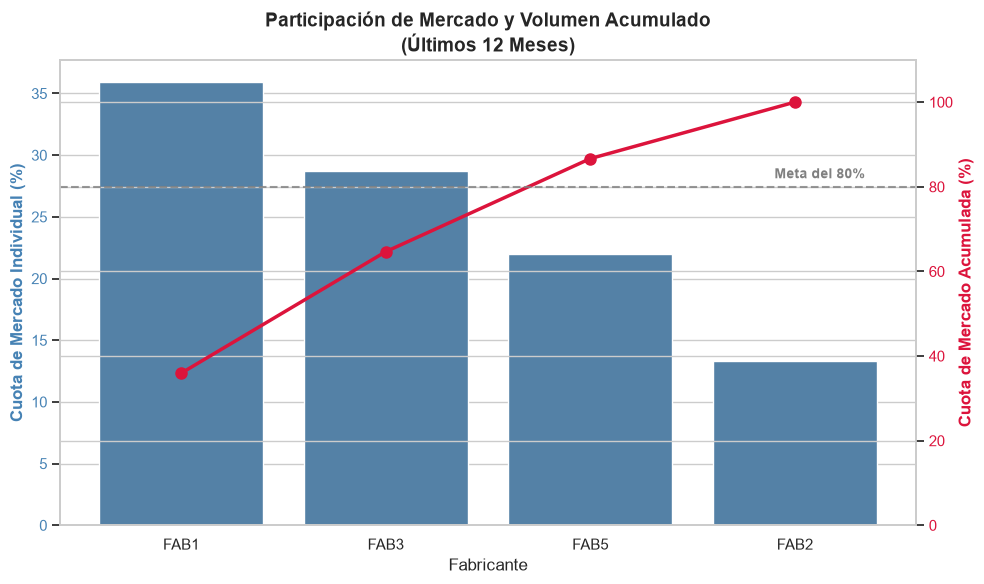


Cuota Acumulada Últimos 12 Meses (%):


FABRICANTE
FAB1     35.93
FAB3     64.65
FAB5     86.65
FAB2    100.00
Name: VENTA_VALOR, dtype: float64

In [29]:
# Cuota de mercado por año (composición histórica)
# Agrupamos y rellenamos nulos con 0 (para los fabricantes que no existían en ciertos años)
ms_year = df.groupby(['AÑO1', 'FABRICANTE'])['VENTA_VALOR'].sum().unstack().fillna(0)
ms_year_pct = ms_year.div(ms_year.sum(axis=1), axis=0) * 100

# Gráfica 1: Evolución anual (Barras apiladas)
sns.set_theme(style="whitegrid")
ms_year_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', edgecolor='white')
plt.title('Evolución de la Cuota de Mercado por Año', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Porcentaje de Mercado (%)', fontsize=12)
plt.legend(title='Fabricante', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(ms_year_pct.round(2))

# 2. TOP FABRICANTES (ÚLTIMOS 12 MESES)
max_date = df['FECHAM'].max()
last_12m_start = max_date - pd.DateOffset(months=11)
df_last12 = df[df['FECHAM'] >= last_12m_start]

ms_last12 = df_last12.groupby('FABRICANTE')['VENTA_VALOR'].sum().sort_values(ascending=False)
ms_last12_pct = ms_last12 / ms_last12.sum() * 100
ms_last12_cum = ms_last12_pct.cumsum()

# Gráfica 2: Pareto de los últimos 12 meses
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje principal (Barras de participación individual)
color1 = 'steelblue'
sns.barplot(x=ms_last12_pct.index, y=ms_last12_pct.values, ax=ax1, color=color1)
ax1.set_xlabel('Fabricante', fontsize=12)
ax1.set_ylabel('Cuota de Mercado Individual (%)', color=color1, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)

# Eje secundario (Línea de participación acumulada)
ax2 = ax1.twinx()
color2 = 'crimson'
ax2.plot(ms_last12_cum.index, ms_last12_cum.values, color=color2, marker='o', linestyle='-', linewidth=2.5, markersize=8)
ax2.set_ylabel('Cuota de Mercado Acumulada (%)', color=color2, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 110)

# Línea punteada marcando la meta del 80%
ax2.axhline(80, color='gray', linestyle='--', alpha=0.8)
ax2.text(len(ms_last12_cum)-1.1, 82, 'Meta del 80%', color='gray', fontsize=10, fontweight='bold')

plt.title('Participación de Mercado y Volumen Acumulado\n(Últimos 12 Meses)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCuota Acumulada Últimos 12 Meses (%):")
display(ms_last12_cum.round(2))

De lo anterior, podemos destacar que:

- Los datos históricos revelan un cambio drástico en el comportamiento del mercado. Entre 2022 y 2023, la categoría estaba dominada por FAB1 y FAB3. Sin embargo, con la llegada de FAB5 en 2024 marcó una diferencia en la industria. Para 2025, FAB5 alcanzó un 26.67% de participación, acaparando a FAB1 (que cayó del 46.43% al 33.72%) y a FAB2 (del 22.65% al 11.62%).
- En contraste, mi fabricante, FAB3, demostró resiliencia manteniendo un volumen notablemente estable (entre 27.98% y 31.55%) durante los cuatro años registrados.

También, al observar la gráfica de los últimos 12 meses, es evidente la alta concentración del mercado actual. Las barras de volumen individual muestran que FAB1 se mantiene como líder (35.93%), seguido muy de cerca por FAB3 (28.72%). La línea de tendencia roja ilustra bien cómo se alcanza el volumen crítico: al sumar el 22.00% que aporta el emergente FAB5, la curva de participación acumulada cruza visiblemente la línea punteada de la "Meta del 80%", llegando a un 86.65%. Esto confirma que solo tres fabricantes controlan casi la totalidad de las ventas de la categoría, dejando a FAB2 relegado y fuera del bloque principal del mercado.

## Objetivo 2: Análisis de Correlación

Para medir la dirección y fuerza de las relaciones lineales entre las variables comerciales de FAB3, realizaré un análisis de correlación de Pearson. Este análisis actuará como un filtro estadístico para detectar redundancias (multicolinealidad) que podrían afectar futuros modelos predictivos, y proporcionará evidencia sobre la interacción entre el precio y el volumen de compra.

Para esto, primero aislaré los registros de FAB3 para detectar redundancias internas entre valor, volumen y precio. Después construiré un panel mensual por fabricante, sumando `VENTA_VALOR` y `LITROS` por `FECHAM` y `FABRICANTE` y recalculando el precio ponderado como $\sum VENTA_VALOR/\sum LITROS$. Con este panel correlacionaré los precios de los fabricantes con historia completa y los volúmenes de los principales competidores. El nivel mensual coincide con la unidad temporal utilizada en los modelos y permite comparar observaciones alineadas.

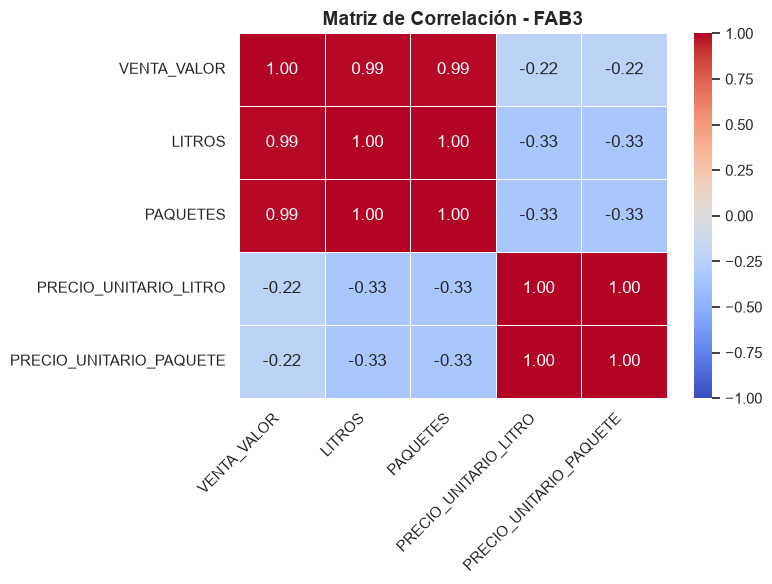

,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
VENTA_VALOR,1.000000,0.989521,0.989521,-0.220211,-0.220211
LITROS,0.989521,1.000000,1.000000,-0.330617,-0.330617
PAQUETES,0.989521,1.000000,1.000000,-0.330617,-0.330617
PRECIO_UNITARIO_LITRO,-0.220211,-0.330617,-0.330617,1.000000,1.000000
PRECIO_UNITARIO_PAQUETE,-0.220211,-0.330617,-0.330617,1.000000,1.000000


In [30]:
# Filtramos el dataframe para aislar al Fabricante 3
df_fab3 = df[df["FABRICANTE"] == "FAB3"]

# Generamos la matriz de correlación con las variables clave
columnas_corr = ['VENTA_VALOR', 'LITROS', 'PAQUETES', 'PRECIO_UNITARIO_LITRO', 'PRECIO_UNITARIO_PAQUETE']
corr = df_fab3[columnas_corr].corr()

# Visualización mediante Heatmap para rápida interpretación
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación - FAB3', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(corr)

La correlación de 0.99 entre `VENTA_VALOR` y `LITROS` confirma la premisa comercial de que el volumen de producto desplazado dicta los ingresos totales de forma directa y casi perfectamente lineal.

Los datos revelan una correlación de -0.33 entre el `PRECIO_UNITARIO_LITRO` y los `LITROS` vendidos, y de -0.22 frente a la `VENTA_VALOR`. Esta relación inversa es la primera validación de la sensibilidad al precio: los incrementos tarifarios contraen el volumen de compra.

El mapa de calor muestra una correlación máxima de 1.00 entre `LITROS` y `PAQUETES`, al igual que entre `PRECIO_UNITARIO_LITRO` y `PRECIO_UNITARIO_PAQUETE`. Esto indica que aportan exactamente la misma varianza al modelo, pues son la misma métrica expresada en unidades distintas. Mantener ambas en un modelo predictivo causaría un error grave de multicolinealidad, distorsionando los coeficientes matemáticos. Lo correcto y más conveniente es eliminar las variables secundarias (`PAQUETES` y `PRECIO_UNITARIO_PAQUETE`) y conservar únicamente la unidad de medida estándar (LITROS y su precio correspondiente) para continuar.

Meses disponibles por fabricante:


,meses
FABRICANTE,
FAB1,43
FAB2,43
FAB3,43
FAB5,13


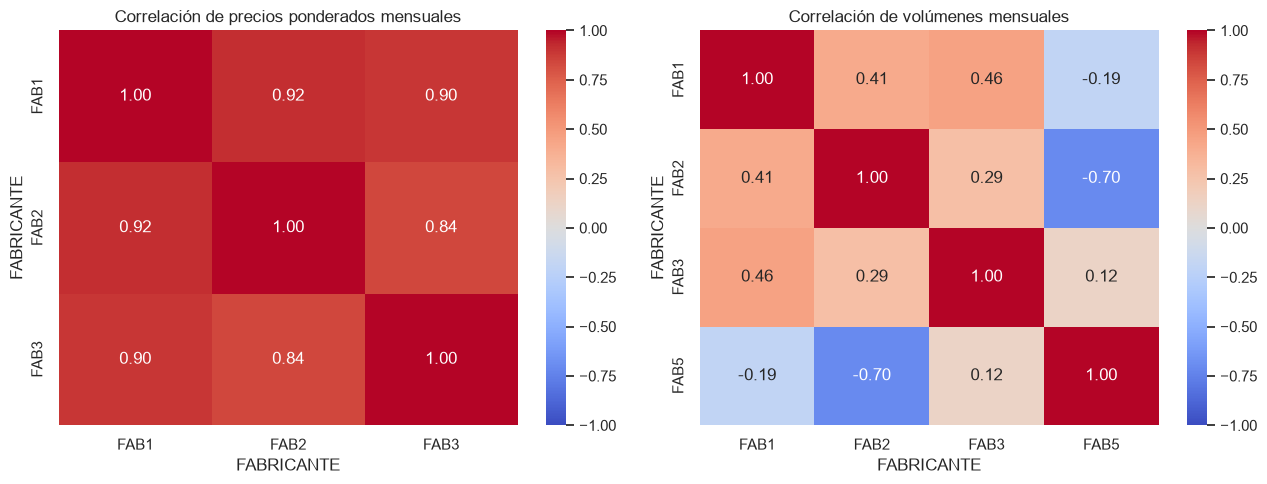

FABRICANTE,FAB1,FAB2,FAB3
FABRICANTE,,,
FAB1,1.000,0.919,0.895
FAB2,0.919,1.000,0.837
FAB3,0.895,0.837,1.000


FABRICANTE,FAB1,FAB2,FAB3,FAB5
FABRICANTE,,,,
FAB1,1.000,0.409,0.460,-0.191
FAB2,0.409,1.000,0.286,-0.705
FAB3,0.460,0.286,1.000,0.118
FAB5,-0.191,-0.705,0.118,1.000


In [31]:
# Correlaciones entre fabricantes a nivel mensual
mercado_fab_mensual = (
    df_mensual
    .groupby(['FECHAM', 'FABRICANTE'], as_index=False)
    .agg(
        VENTA_VALOR=('VENTA_VALOR', 'sum'),
        LITROS=('LITROS', 'sum')
    )
)

# Precio ponderado correcto de cada fabricante
mercado_fab_mensual['PRECIO_PONDERADO_LITRO'] = (
    mercado_fab_mensual['VENTA_VALOR']
    / mercado_fab_mensual['LITROS']
)

precios_fab = mercado_fab_mensual.pivot(
    index='FECHAM',
    columns='FABRICANTE',
    values='PRECIO_PONDERADO_LITRO'
)

volumenes_fab = mercado_fab_mensual.pivot(
    index='FECHAM',
    columns='FABRICANTE',
    values='LITROS'
)

# FAB1, FAB2 y FAB3 tienen la historia completa de 43 meses.
# FAB5 se incluye en volumen para estudiar su entrada al mercado.
corr_precios_competidores = precios_fab[
    ['FAB1', 'FAB2', 'FAB3']
].corr()

corr_volumenes_competidores = volumenes_fab[
    ['FAB1', 'FAB2', 'FAB3', 'FAB5']
].corr()

print("Meses disponibles por fabricante:")
display(
    precios_fab[['FAB1', 'FAB2', 'FAB3', 'FAB5']]
    .count()
    .to_frame('meses')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    corr_precios_competidores,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=axes[0]
)
axes[0].set_title('Correlación de precios ponderados mensuales')

sns.heatmap(
    corr_volumenes_competidores,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=axes[1]
)
axes[1].set_title('Correlación de volúmenes mensuales')

plt.tight_layout()
plt.show()

display(corr_precios_competidores.round(3))
display(corr_volumenes_competidores.round(3))

Al comparar fabricantes a nivel mensual, los precios ponderados de FAB1, FAB2 y FAB3 presentan correlaciones positivas altas, entre 0.837 y 0.919. Esto probablemente refleja factores comunes como inflación, costos de insumos y movimientos generales de la categoría. También implica que incluir varios precios de competidores simultáneamente en una regresión podría generar multicolinealidad, por lo que sería necesario revisar el VIF.

En los volúmenes, la relación inversa más fuerte es FAB2–FAB5, con una correlación de −0.705 durante los 13 meses en los que FAB5 está presente. El resultado es consistente con una posible sustitución o desplazamiento de FAB2 tras la entrada de FAB5, aunque no demuestra causalidad porque la entrada del nuevo fabricante también coincide con cambios temporales del mercado.


In [32]:
df_fab3 = df_fab3.drop(columns=['PAQUETES', 'PRECIO_UNITARIO_PAQUETE'])
print("\nColumnas 'PAQUETES' y 'PRECIO_UNITARIO_PAQUETE' eliminadas. Dataset listo para el Objetivo 3.")


Columnas 'PAQUETES' y 'PRECIO_UNITARIO_PAQUETE' eliminadas. Dataset listo para el Objetivo 3.


## Objetivo 3: Modelo de Regresión (Sensibilidad al Precio)

Ahora, realizaremos un calculo para la elasticidad del precio de la demanda para el producto estrella de FAB3. Para esto, primero, filtraremos los datos de los últimos 12 meses para identificar el producto con mayor volumen de ventas histórico (`LITROS`). Una vez aislado este artículo, tendremos que limpiar la base eliminando valores nulos o ceros. Esto paso es necesario antes de aplicar transformaciones matemáticas.

Se implementará un modelo de regresión lineal por mínimos cuadrados ordinarios (`OLS`) empleando la librería `statsmodels` en un formato `log-log`: $\ln(Q) = \beta_0 + \beta_1 \ln(P)$.

La gran ventaja de esta transformación es que el coeficiente resultante ($\beta_1$) representa directamente la elasticidad del producto, es decir, dictará qué porcentaje exacto varía el volumen de venta por cada 1% que se modifique el precio.

In [33]:
# Identificamos el producto estrella en los datos mensuales
max_date = df_mensual['FECHAM'].max()
last_12m_start = max_date - pd.DateOffset(months=11)
df_fab3_last12 = df_fab3_mensual[df_fab3_mensual['FECHAM'] >= last_12m_start]

top_last12 = df_fab3_last12.groupby('PRODUCTO')['LITROS'].sum().sort_values(ascending=False)
print("Ranking de productos FAB3 por litros — ÚLTIMOS 12 MESES:")
display(top_last12)

top_product = top_last12.idxmax()
print(f"\nProducto estrella (correcto, últimos 12 meses): {top_product}")

# Preparamos los datos mensuales para el modelo
df_top_mensual = df_fab3_mensual[df_fab3_mensual['PRODUCTO'] == top_product].copy()
df_top_mensual = df_top_mensual[(df_top_mensual['LITROS'] > 0) & (df_top_mensual['PRECIO_UNITARIO_LITRO'] > 0)]
df_top_mensual = df_top_mensual.sort_values('FECHAM').reset_index(drop=True)

# Transformación Log-Log
df_top_mensual['ln_Q'] = np.log(df_top_mensual['LITROS'])
df_top_mensual['ln_P'] = np.log(df_top_mensual['PRECIO_UNITARIO_LITRO'])

# Ejecución del Modelo OLS
X = sm.add_constant(df_top_mensual['ln_P'])
y = df_top_mensual['ln_Q']
model_base = sm.OLS(y, X).fit()
print(model_base.summary())

Ranking de productos FAB3 por litros — ÚLTIMOS 12 MESES:


PRODUCTO
FAB3_1L  Ent Entera                 4609644
FAB3_1L  Desl Deslactosada          3298020
FAB3_1L  D Li Deslactosada Light     994944
Name: LITROS, dtype: int64


Producto estrella (correcto, últimos 12 meses): FAB3_1L  Ent Entera
                            OLS Regression Results                            
Dep. Variable:                   ln_Q   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     19.55
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           7.05e-05
Time:                        12:44:35   Log-Likelihood:                 5.6528
No. Observations:                  43   AIC:                            -7.306
Df Residuals:                      41   BIC:                            -3.783
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

### Interpretacion de los datos

Primero, tenemos que la demanda de $\beta_1$ (ln_P) es igual a $-1.7656$, por lo que nos indica que la demandas es elástica. Por cada 1% que sube el precio, el volumen cae 1.77%, manteniendo todo lo demás constante dentro de este modelo (que sólo incluye el precio).

Después, tenemos que el t-value es $t=-4.42$ y el valor es $p=7.05\times10^{-5}$, es decir, $p<0.001$. Existe una asociación estadísticamente significativa entre precio y volumen, aunque esto no prueba una relación causal.

También, tenemos que el IC al 95% es de [-2.572, -0.959]. Lo más interaste es señalar que todo el intervalo está por debajo de -1, es decir, con 95% de confianza, la demanda no solo es negativa, sino específicamente elástica.

Por último, tenemos que $R^2 = 0.323$. El precio por sí solo explica el 32.3% de la variación del volumen mensual. El 67.7% resstante depende de otros factores que no se incluyen con este modelo.

**Limitaciones**

1. **Causalidad vs. asociación**: el precio en retail suele fijarse en función de la demanda esperada o de costos. Un p-value bajo confirma que la relación no es ruido, pero no nos confirma que mover el precio artificialmente produzca ese mismo efecto.
2. **Sesgo por variable omitida**: no se controla tendencia ni estacionalidad. Si el volumen crece con el tiempo por razones ajenas al precio y el precio también sube con el tiempo (por ejemplo, por la inflación), el coeficiente del precio puede estar sesgado.
3. **Autocorrelación**: el Durbin-Watson de este modelo mensual es 2.18. Lo que nos indica este valor es para evaluar que tanto los errores de un modelo están relacionados entre sí. En nuestro caso, al ser cercano a 2, nos indica que no hay una autocorrelación fuerte entre estos.
4. **Endogeneidad del precio por su construcción**: el precio mensual se calcula como $\sum VENTA_VALOR/\sum LITROS$, por lo que comparte el volumen en el denominador. Además, durante una promoción el precio efectivo suele bajar al mismo tiempo que aumentan los litros vendidos. Esto hace que precio y volumen se determinen conjuntamente y puede reforzar mecánicamente su relación negativa. Por ello, el coeficiente debe interpretarse como asociación y no como un efecto causal puro.

# Parte 2: Modelación de los datos
## Objetivo 4 — Diseño propuesto para incorporar elasticidad cruzada, estacionalidad y tendencia

**Propuesta de mejora**

Para mejorar el modelo, se puede agregra la elasticidad curzada, la tendencia y la estacionalidad de la siguiente forma:

$$ \ln (Q_t) = \beta_0 + \beta_1 \cdot \ln(P_{\text{propio}, t}) + \sum_j \gamma_j \cdot \ln(P_{\text{competidor-}j, t}) + \theta \cdot \text{trend}_t + \sum_m \delta_m \cdot \text{Mes}_m + \epsilon_t $$

Para capturar la elasticidad cruzada ($\gamma_j$), se puede agregar el precio de productos sustitutos (es decir, la competencia) cercanos. Con los datos disponibles hay dos niveles posibles: dentro del portafolio de `FAB3`, el precio de `FAB3_1L Desl Deslactosada` frente al de `FAB3_1L Ent Entera` capturaría la canibalización interna entre presentaciones del mismo fabricante; frente a competidores directos, el precio de la entera de FAB1 (`FAB1_Leche Clasica Entera 1 L`, el líder histórico) o de FAB5 (`FAB5_Mm 12/1L Leche Ente Members Mark`, el disruptor que le quitó cuota a FAB1 y FAB2 desde 2024). Esto capturaría la sustitución entre marcas. Se esperaría que $\gamma_j > 0$ indique sustitutos (sube el precio del competidor, sube el volumen en `FAB3`), mientras que $\gamma_j < 0$ indicaría complementos, algo poco probable en este caso pero que se reportaría si apareciera.

La tendencia ($\theta$, `trend_t`), representada como un índice de tiempo (1, 2, 3…), capturaría el crecimiento o caída estructural del volumen que no depende del precio, como la expansión de distribución, cambios en el hábito de consumo, o la entrada de nuevos jugadores como FAB5. Por su parte, la estacionalidad ($\delta_m$) se modelaría con dummies de mes o, si el tamaño de muestra es limitado, con términos armónicos seno/coseno de periodo 12 (como se hace en el Objetivo 5), para capturar patrones repetitivos dentro del año que sean independientes del precio y de la tendencia.

Al diseñar este modelo hay algunos riesgos que vigilar. Primero, la multicolinealidad entre `trend` y `ln_P` propio, porque el precio casi siempre sube con el tiempo por inflación — conviene revisar el VIF y, si es necesario, usar precio real (deflactado) en vez de nominal. También hay que considerar los grados de libertad: con solo ~43-48 observaciones mensuales, cada variable adicional (sobre todo 11 dummies de mes) consume mucha información, como se ve en el problema real que esto causa en el Objetivo 5. Por último, dado que se detectó cierta autocorrelación residual, conviene estimar con errores estándar tipo Newey-West (HAC) en vez de los OLS clásicos.

## Objetivo 5 - Implementación del modelo

Dado lo anterior, el modelo quedaría de la siguiente forma en python.

In [34]:
df_top_mensual['trend'] = np.arange(1, len(df_top_mensual) + 1)
df_top_mensual['sin1'] = np.sin(2 * np.pi * df_top_mensual['FECHAM'].dt.month / 12)
df_top_mensual['cos1'] = np.cos(2 * np.pi * df_top_mensual['FECHAM'].dt.month / 12)
month_dummies = pd.get_dummies(df_top_mensual['FECHAM'].dt.month, prefix='m', drop_first=True).astype(float)

# Solo tendencia (sin estacionalidad todavía)
X_trend = sm.add_constant(df_top_mensual[['ln_P', 'trend']])
model_trend = sm.OLS(df_top_mensual['ln_Q'], X_trend).fit()
print("=== Precio + Tendencia ===")
print(model_trend.summary())

# Tendencia + 11 dummies de mes
X_dum = pd.concat([df_top_mensual[['ln_P', 'trend']], month_dummies], axis=1)
X_dum = sm.add_constant(X_dum)
model_dummies = sm.OLS(df_top_mensual['ln_Q'], X_dum).fit()
print("\n=== Precio + Tendencia + 11 dummies de mes ===")
print(model_dummies.summary())

# VIF para diagnosticar el problema de las 11 dummies
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['variable'] = X_dum.columns
vif_data['VIF'] = [variance_inflation_factor(X_dum.values, i) for i in range(X_dum.shape[1])]
print("\nVIF (modelo con 11 dummies):")
display(vif_data)

# Tendencia + estacionalidad armónica
X_fourier = sm.add_constant(df_top_mensual[['ln_P', 'trend', 'sin1', 'cos1']])
model_final = sm.OLS(df_top_mensual['ln_Q'], X_fourier).fit()
print("\n=== MODELO FINAL: Precio + Tendencia + Estacionalidad armónica ===")
print(model_final.summary())

=== Precio + Tendencia ===
                            OLS Regression Results                            
Dep. Variable:                   ln_Q   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     14.50
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           1.84e-05
Time:                        12:44:35   Log-Likelihood:                 8.9916
No. Observations:                  43   AIC:                            -11.98
Df Residuals:                      40   BIC:                            -6.700
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.7833    

,variable,VIF
0,const,1.000000
1,ln_P,13.405343
2,trend,11.753312
3,m_2,2.036435
4,m_3,1.821776
5,m_4,2.370017
6,m_5,2.257114
7,m_6,2.162484
8,m_7,2.171967
9,m_8,1.662949



=== MODELO FINAL: Precio + Tendencia + Estacionalidad armónica ===
                            OLS Regression Results                            
Dep. Variable:                   ln_Q   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     6.958
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           0.000264
Time:                        12:44:35   Log-Likelihood:                 9.0845
No. Observations:                  43   AIC:                            -8.169
Df Residuals:                      38   BIC:                            0.6370
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

Hay que destacar que, para le modelo final, se utiliza seno y coseno y no once *dummies* para los meses. Con sólo 43 observaciones, meter 11 dumies de mes + precio + tendencia dejan apenas ~29 grados de libretad, y el VIF de `ln_P` y `tren` se dispara por arriba de 10, lo que indica una evidencia de multicolinealidad grande. Además, cada mes aparecen sólo 3-4 veces en toda la muestra, así que las varibles *dummies* terminarían absorbiendo variacion que, en realidad, le pretence al precio y a la tendencia. El resultao de esto es que el coeficiente del precio se vuelve no significativo (con un $p\approx 0.13$), no porque el precio haya dejado de importar, sino porque el modelo esá sobreajustado. La alternativa es utilizar entonces funciones trigonometricas, que hacen lograr el mismo objetivo; controlar el patron repetititvo dentro del año con sólo dos parámateros en vez de once. Preserva además grados de libertad y mantinene el VIF en un rango razonable.

### Interpretación del modelo final

Primero, tenemos que $\beta_1$ (ln_P) es igual a $-4.0091$, con $t=-3.98$ y $p=0.0003$. Una vez que se aísla el efecto de la tendencia y la estacionalidad, la elasticidad-precio resulta mucho más elástica de lo que sugería el modelo simple, y sigue siendo altamente significativa.

Después, tenemos que $\theta$ (trend) es igual a $0.0164$, con $t=2.46$ y $p=0.018$. Esto nos indica que hay una tendencia de crecimiento del volumen, independiente del precio, de aproximadamente 1.65% mensual, ya que $(e^{0.0164}-1)\times100=1.65%$. Algo consistente con lo que se veía en la primera parte, donde el mercado como categoría no es estático.

También, tenemos que los términos estacionales (`sin1`, `cos1`) no son significativos individualmente ($p=0.88$ y $p=0.71$). Con estos datos no hay evidencia de un patrón estacional fuerte para este SKU, lo cual tiene sentido para un producto de consumo básico como la leche entera, a diferencia de otros productos que sí son por temporadas, como productos navideños.

Por último, el $R^2$ sube de 0.323 (modelo base) a 0.423 (modelo final). Al incorporar la tendencia se explica una porción adicional relevante de la variación del volumen que antes quedaba, incorrectamente, mezclada con el efecto del precio.

### Entonces ¿Cambio la estimación con respecto al modelo anterior?

En cuanto a si cambió la estimación de elasticidad-precio respecto al modelo anterior, la respuesta es bastante clara: sí, y bastante. Pasó de -1.77 (modelo solo-precio) a -4.01 (modelo con tendencia). La demanda resulta mucho más elástica de lo que el primer modelo indicaba.

Sobre qué pasó con la significancia estadística, con tendencia (o con tendencia + estacionalidad armónica) el precio se mantiene muy significativo ($p<0.001$). Solo se pierde la significancia si se usa la especificación de 11 dummies, y ahí la causa es sobreajuste y multicolinealidad, no que el precio deje de influir.

Finalmente, por qué cambia la estimación y cuál es la mejor: el modelo simple sufría sesgo por variable omitida, ya que el precio subía con el tiempo por inflación al mismo tiempo que el volumen crecía por razones estructurales ajenas al precio. Al no controlar la tendencia, parte del efecto positivo de "crecimiento con el tiempo" se mezclaba con el coeficiente de precio, empujándolo hacia cero (menos elástico de lo real). Al agregar la tendencia, se aísla el efecto puro del precio, y resulta ser más negativo, es decir, más elástico. La mejor estimación es la del modelo con tendencia + estacionalidad armónica, porque corrige el sesgo de variable omitida sin caer en el sobreajuste de las 11 dummies.


## Objetivo 6. Propuesta de pronóstico a 24 meses.

**Investigación / comparación de enfoques posibles.**
| Enfoque | Ventajas | Riesgos con estos datos (n≈43-48 meses) |
|---|---|---|
| Extender la regresión con `trend` futuro + estacionalidad | Simple, interpretable, conecta directo con la elasticidad ya estimada | El precio es exógeno: hay que pronosticarlo aparte o suponer escenarios |
| Suavizamiento exponencial (Holt-Winters) | Diseñado justo para tendencia + estacionalidad, pocos parámetros | No incorpora el precio como palanca de decisión |
| ARIMA / SARIMA / SARIMAX (precio como regresor exógeno) | Modela explícitamente la autocorrelación que vimos en los residuales | Requiere series razonablemente largas para estimar bien los términos AR/MA estacionales |
| Prophet (Meta) | Maneja tendencia + estacionalidad + cambios de pendiente casi automáticamente | Pensado para series diarias/semanales largas; con 43 puntos mensuales es un martillo para un clavo pequeño |
| XGBoost/LightGBM con rezagos, medias móviles, mes | Captura no linealidades y quiebres | Con ~43 observaciones el riesgo de sobreajuste es alto; necesitaría validación cuidadosa |
| LSTM/GRU | Teóricamente muy flexible | Se necesita cientos/miles de observaciones; no  se puede recomendar en este caso, la muestra es demasiado chica |

**Recomendación:** dado que solo hay ~43-48 observaciones mensuales y se quiere pronosticar 24 meses (casi el 60% del histórico), conviene privilegiar modelos parsimoniosos y auditables sobre modelos de alta capacidad como ML/DL. La propuesta concreta consiste en pronosticar primero el precio con su propio modelo de tendencia y estacionalidad. Dado que el precio es una variable de decisión del fabricante y del canal, en la práctica también conviene generar escenarios (optimista, base, pesimista) en vez de un solo pronóstico determinístico. Después, se pronosticaría el volumen alimentando el precio pronosticado (o cada escenario de precio) al modelo de elasticidad, junto con el índice de tendencia futuro y los términos estacionales futuros. Antes de confiar en el pronóstico a 24 meses, conviene validarlo con backtesting tipo rolling-origin, entrenando con datos hasta el mes $t$ y pronosticando $t+1 \dots t+h$ para comparar contra lo real. Por último, siempre hay que reportar un intervalo de predicción y no solo el punto estimado, ya que con una muestra chica y un horizonte largo, la incertidumbre crece rápido.